In [40]:
import pandas as pd

census = pd.read_csv("../processed_data/census_demographics.csv", dtype={'tract_code': str})
incidents = pd.read_csv("../processed_data/sf_incidents_with_tracts.csv")

In [13]:
incidents.head()

,incident_number,calendaryear,month,incdate,problem,responsearea,council_district,location,longitude,latitude,census_tracts,tract_codes
0,22000037,2022,Jan,01/01/2022 12:00:00 AM,BOX -Structure Fire,00-2306,4,"(-97.692635,30.364969)",-97.692635,30.364969,['410'],['041000']
1,22000085,2022,Jan,01/01/2022 12:00:00 AM,BOXS - Still Box Alarm,00-1407,4,"(-97.714795,30.316076)",-97.714795,30.316076,['15.03'],['001503']
2,22000122,2022,Jan,01/01/2022 12:00:00 AM,BOXL- Structure Fire,00-4104,1,"(-97.612957,30.372331)",-97.612957,30.372331,['449'],['044900']
3,22000252,2022,Jan,01/01/2022 12:00:00 AM,BOX -Structure Fire,00-1709,3,"(-97.765376,30.213776)",-97.765376,30.213776,['24.03'],['002403']
4,22000440,2022,Jan,01/01/2022 12:00:00 AM,BOX -Structure Fire,00-2306,4,"(-97.691949,30.359055)",-97.691949,30.359055,['431'],['043100']


In [30]:
import ast

def parse_census_tracts(tract_str):
    """
    Parse census tract string from incidents file.
    Input: string like "['410']" or "['15.03']" or "['2.04', '2.03']"
    Returns: list of tract codes, or empty list if parsing fails
    """
    if pd.isna(tract_str) or tract_str == '':
        return []
    try:
        # Remove any whitespace
        tract_str = str(tract_str).strip()
        # Try to evaluate as Python literal
        tracts = ast.literal_eval(tract_str)
        if isinstance(tracts, str):
            return [tracts]
        elif isinstance(tracts, list):
            return [str(t) for t in tracts]
        else:
            return []
    except:
        return []
    
def explode_incidents_by_tract(incidents_df):
     ### Since we're exploding by tract, we need to make sure to average out the census demographics in the case of boundaries.
    """
    Create one row per incident-tract combination.
    For incidents in multiple tracts, duplicate the row.
    """
    print("\nExploding incidents by tract...")
    
    # Create list of incident-tract pairs
    pairs = []
    for idx, row in incidents_df.iterrows():
        tracts = row['tract_list']
        if len(tracts) > 0:
            for tract in tracts:
                pairs.append({**row.to_dict(), 'tract_code': tract})
    
    # Convert to dataframe
    exploded = pd.DataFrame(pairs)
    
    return exploded

In [31]:
incidents['tract_list'] = incidents['tract_codes'].apply(parse_census_tracts)
exp_df = explode_incidents_by_tract(incidents)


Exploding incidents by tract...


In [34]:
incidents[incidents['tract_list'].apply(lambda x: len(x) > 1)]

,incident_number,calendaryear,month,incdate,problem,responsearea,council_district,location,longitude,latitude,census_tracts,tract_codes,tract_list
34,22003662,2022,Jan,01/07/2022 12:00:00 AM,BOXL- Structure Fire,00-0303,9,"(-97.741431,30.304425)",-97.741431,30.304425,"['2.04', '2.03']","['000204', '000203']","[000204, 000203]"
54,22007278,2022,Jan,01/15/2022 12:00:00 AM,BOX -Structure Fire,00-2203,3,"(-97.717205,30.237520)",-97.717205,30.237520,"['23.24', '23.26']","['002324', '002326']","[002324, 002326]"
69,22009976,2022,Jan,01/20/2022 12:00:00 AM,BOX -Structure Fire,05-4604,-,"(-97.853297,30.178153)",-97.853297,30.178153,"['313', '319']","['031300', '031900']","[031300, 031900]"
85,22011294,2022,Jan,01/23/2022 12:00:00 AM,BOX -Structure Fire,00-1706,3,"(-97.765313,30.233119)",-97.765313,30.233119,"['13.08', '13.07']","['001308', '001307']","[001308, 001307]"
100,22012115,2022,Jan,01/24/2022 12:00:00 AM,BOX -Structure Fire,00-0301,9,"(-97.743918,30.295922)",-97.743918,30.295922,"['6.06', '6.05', '2.04']","['000606', '000605', '000204']","[000606, 000605, 000204]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2909,24143162,2024,Oct,10/13/2024 12:00:00 AM,BOXMID -MIDRISE Structure Fire,00-2206,3,"(-97.706991,30.220168)",-97.706991,30.220168,"['23.20', '23.14']","['002320', '002314']","[002320, 002314]"
2955,24150929,2024,Oct,10/28/2024 12:00:00 AM,BOXL- Structure Fire,04-3305,10,"(-97.783577,30.399873)",-97.783577,30.399873,"['305', '326']","['030500', '032600']","[030500, 032600]"
3042,24165865,2024,Nov,11/26/2024 12:00:00 AM,BOXS - Still Box Alarm,00-1706,3,"(-97.763028,30.236734)",-97.763028,30.236734,"['13.08', '13.07']","['001308', '001307']","[001308, 001307]"
3052,24166732,2024,Nov,11/28/2024 12:00:00 AM,BOX -Structure Fire,00-0201,9,"(-97.741991,30.282642)",-97.741991,30.282642,"['6.08', '6.01']","['000608', '000601']","[000608, 000601]"


In [43]:
analysis_df = df[['median_income', 'pct_built_2010_plus']].copy()
analysis_df = analysis_df[
    (analysis_df['median_income'] > 0) &
    analysis_df['pct_built_2010_plus'].notna()
]

analysis_df['income_bin'] = pd.cut(analysis_df['median_income'], bins=5, include_lowest=True)
analysis_df['built_bin'] = pd.cut(analysis_df['pct_built_2010_plus'], bins=5, include_lowest=True)

bivariate_counts = analysis_df.groupby(['income_bin', 'built_bin']).size().unstack(fill_value=0)
bivariate_counts

built_bin,"(-0.0855, 16.899]","(16.899, 33.798]","(33.798, 50.697]","(50.697, 67.596]","(67.596, 84.495]"
income_bin,,,,,
"(3547.792, 53035.4]",453,40,0,17,0
"(53035.4, 102276.8]",928,498,297,128,18
"(102276.8, 151518.2]",291,93,99,28,32
"(151518.2, 200759.6]",51,63,7,0,0
"(200759.6, 250001.0]",41,0,0,0,0


In [45]:
agg_inc = exp_df.groupby('tract_code').agg({
    'incident_number': 'count',
})
agg_inc.rename(columns={'incident_number': 'incident_count'}, inplace=True)
agg_inc.head()

,incident_count
tract_code,
000101,22
000102,10
000203,9
000204,16
000205,13


In [50]:
df = census.merge(agg_inc, left_on='tract_code', right_on='tract_code', how='left')

In [57]:
df = df[df['median_income'] > 0]

<Axes: xlabel='median_income', ylabel='incident_count'>

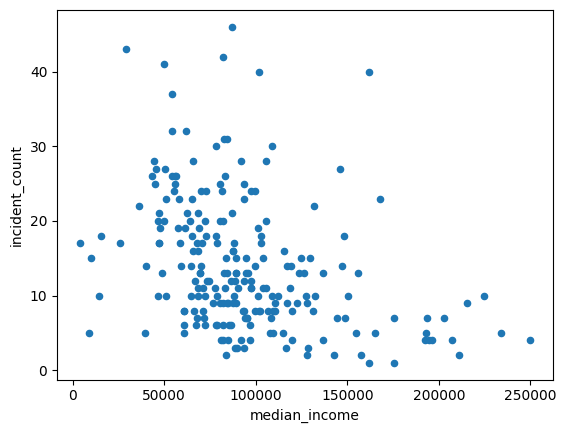

In [58]:
df.plot(x='median_income', y='incident_count', kind='scatter')

In [ ]:
df_bivar = df.copy()
df_bivar['incident_count'] = df_bivar['incident_count'].fillna(0)

df_bivar = df_bivar[
    (df_bivar['median_income'] > 0) &
    df_bivar['pct_built_2010_plus'].notna()
]

df_bivar['income_bin'] = pd.cut(df_bivar['median_income'], bins=5, include_lowest=True)
df_bivar['built_bin'] = pd.cut(df_bivar['pct_built_2010_plus'], bins=5, include_lowest=True)

bivariate_summary = df_bivar.groupby(['income_bin', 'built_bin'])['incident_count'].agg(
    incident_count_mean='mean',
    incident_count_sum='sum',
    tract_count='size'
).reset_index()

bivariate_summary

pivot_mean = bivariate_summary.pivot(index='income_bin', columns='built_bin', values='incident_count_mean')
pivot_sum = bivariate_summary.pivot(index='income_bin', columns='built_bin', values='incident_count_sum')

pivot_mean.plot(kind='bar', figsize=(12, 5), title='Mean incident_count by income and pct_built_2010_plus bins')
pivot_sum.plot(kind='bar', figsize=(12, 5), title='Sum incident_count by income and pct_built_2010_plus bins')